In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

In [2]:
train_dataset = torchvision.datasets.MNIST(
        root='.', 
        train=True, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)
        ])
    )

In [3]:
len(train_dataset)

60000

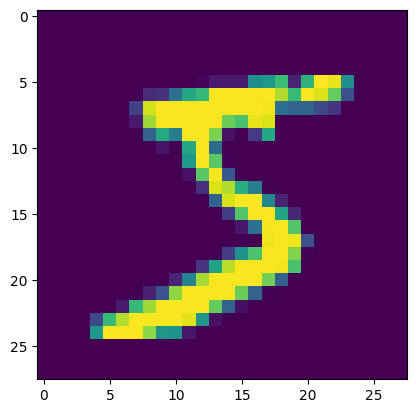

In [4]:
plt.imshow(train_dataset[0][0][0])

In [5]:
train_dataset[0][0][0].min(), train_dataset[0][0][0].mean(), train_dataset[0][0][0].max()

(tensor(-1.), tensor(-0.7246), tensor(1.))

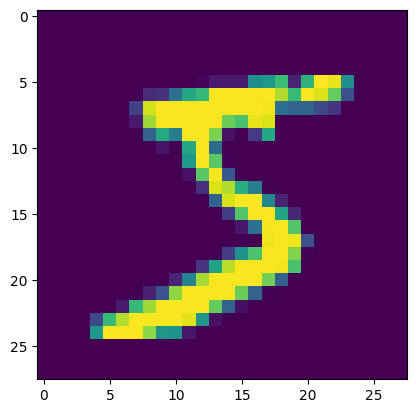

0
tensor(0.)


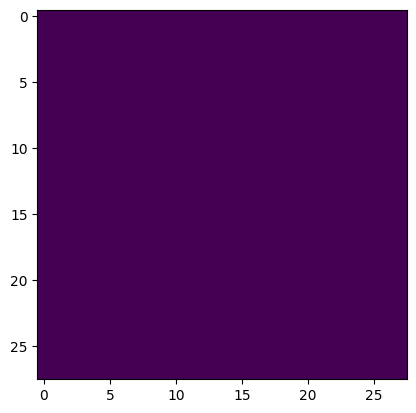

1
tensor(-0.7246)


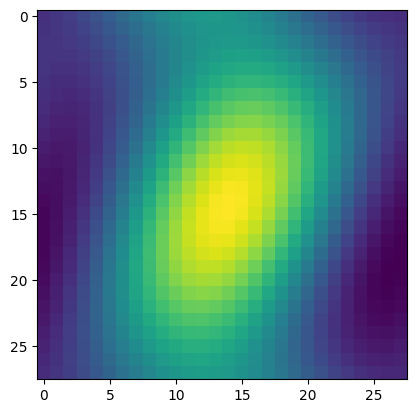

2
tensor(-0.7246)


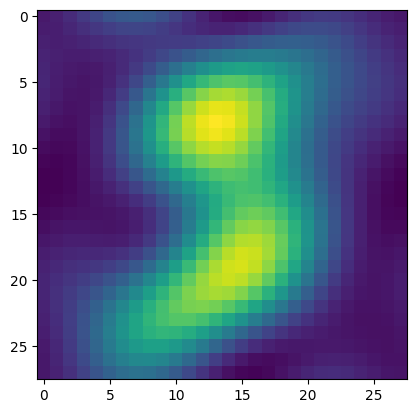

3
tensor(-0.7246)


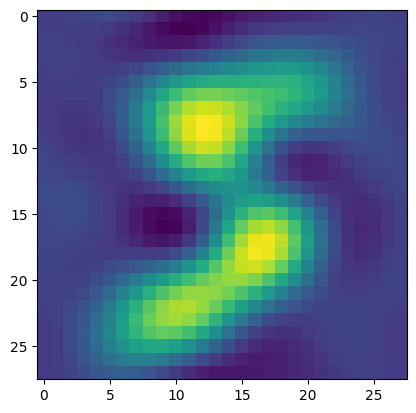

4
tensor(-0.7246)


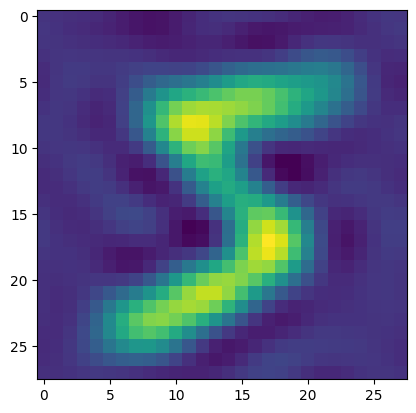

5
tensor(-0.7246)


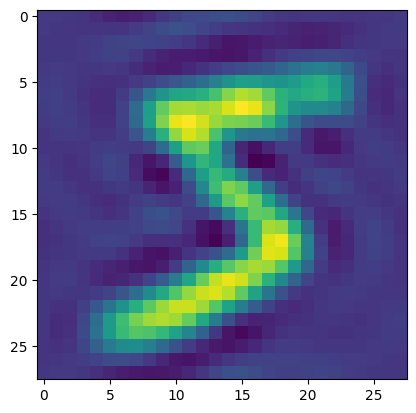

6
tensor(-0.7246)


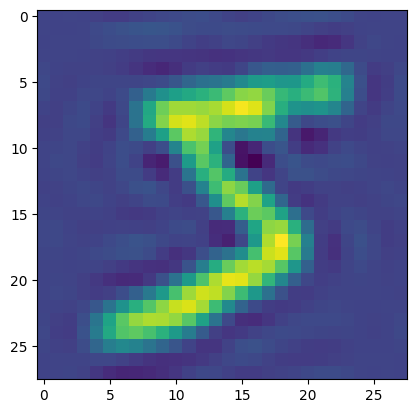

7
tensor(-0.7246)


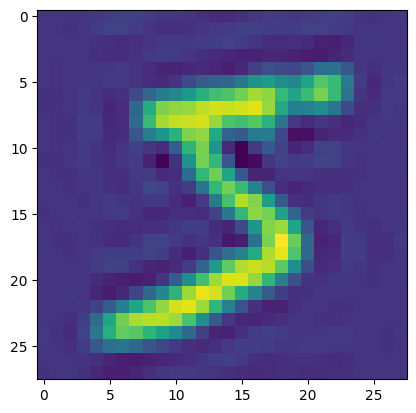

8
tensor(-0.7246)


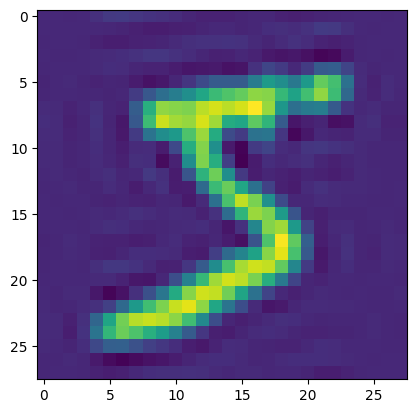

9
tensor(-0.7246)


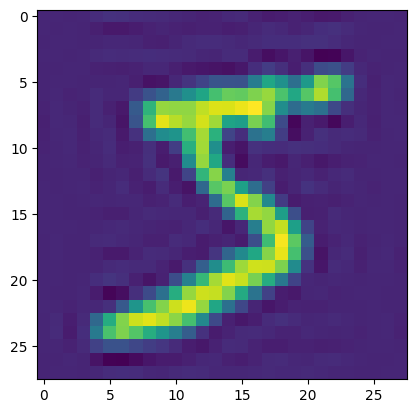

10
tensor(-0.7246)


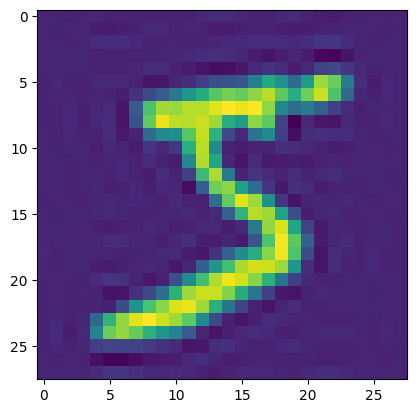

11
tensor(-0.7246)


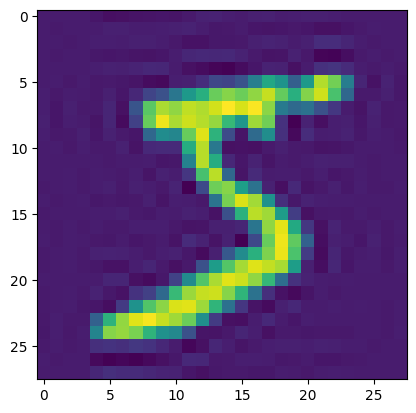

12
tensor(-0.7246)


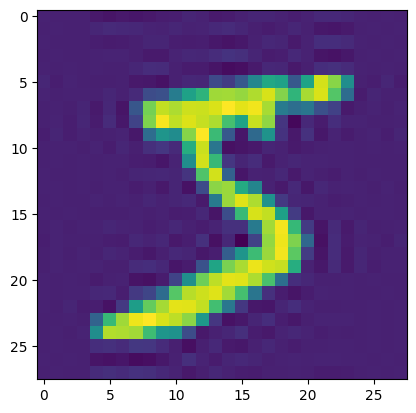

13
tensor(-0.7246)


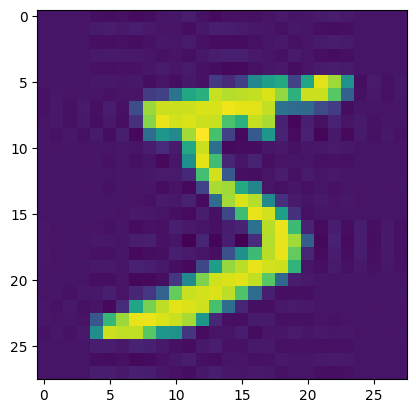

14
tensor(-0.7246)


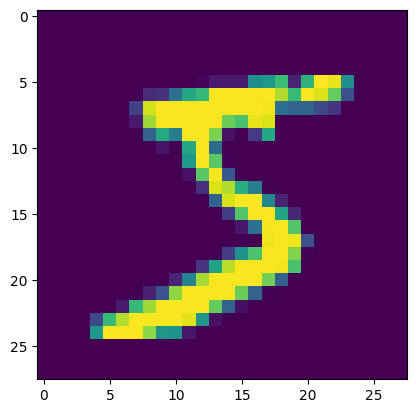

In [6]:
our_sample = train_dataset[0][0][0]
plt.imshow(our_sample)
plt.show()

for n in range(0, train_dataset[0][0][0].shape[0] // 2 + 1):
    print(n)
    fft = torch.fft.fft2(our_sample)
    shifted_fft = torch.fft.fftshift(fft)
    if n != our_sample.shape[0] // 2 :
        shifted_fft[:, :(our_sample.shape[0] // 2 - n)] = 0
        shifted_fft[:(our_sample.shape[0] // 2 - n), :] = 0
        shifted_fft[:, -(our_sample.shape[0] // 2 - n):] = 0
        shifted_fft[-(our_sample.shape[0] // 2 - n):, :] = 0
        
    un_shifted_fft = torch.fft.ifftshift(shifted_fft)
    restored_sample = torch.fft.ifft2(un_shifted_fft).real
    
    print(restored_sample.mean())
    plt.imshow(restored_sample)
    plt.show()

In [7]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        root='.', 
        train=False, 
        transform=transforms.ToTensor(),
    ),
    batch_size=128, shuffle=True
)

In [8]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0]).to(x.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size).to(x.device))
        emb = x.unsqueeze(-1).float() * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t_emb):
        h = self.norm1(F.gelu(self.conv1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(F.gelu(self.conv2(h)))
        return h


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        skip = self.conv(x, t_emb)
        return self.pool(skip), skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x, t_emb)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_ch=64, time_emb_dim=128):
        super().__init__()
        
        self.time_proj = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU()
        )
        
        self.down1 = DownBlock(in_channels, base_ch, time_emb_dim)      # 28 -> 14
        self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)      # 14 -> 7
        
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)
        
        self.up1 = UpBlock(base_ch * 4, base_ch * 2, time_emb_dim)      # 7 -> 14
        self.up2 = UpBlock(base_ch * 2, base_ch, time_emb_dim)          # 14 -> 28
        
        self.out = nn.Conv2d(base_ch, in_channels, 1)

    def forward(self, x, t):
        '''
        :x input [bs, C, H, W] - image
        :t 1d torch.LongTensor of timesteps
        '''
        t_emb = self.time_proj(t)
        
        x, skip1 = self.down1(x, t_emb)
        x, skip2 = self.down2(x, t_emb)
        
        x = self.bottleneck(x, t_emb)
        
        x = self.up1(x, skip2, t_emb)
        x = self.up2(x, skip1, t_emb)
        
        return self.out(x)

In [9]:
DEVICE = "cuda:0"

In [10]:
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [11]:
sum([p.numel() for p in model.parameters()])

1910017

In [12]:
# def fft_forward_process(image, t, max_t=14):
#     fft = torch.fft.fft2(image)
#     shifted_fft = torch.fft.fftshift(fft)
    
#     shifted_fft[:, :max_t - t] = 0
#     shifted_fft[:max_t - t, :] = 0
#     shifted_fft[:, -max_t + t:] = 0
#     shifted_fft[-max_t + t:, :] = 0

#     un_shifted_fft = torch.fft.ifftshift(shifted_fft)
#     restored_sample = torch.fft.ifft2(un_shifted_fft).real

#     return restored_sample


def fft_forward_process(image, t):
    fft = torch.fft.fft2(image)
    shifted_fft = torch.fft.fftshift(fft, dim=(-2, -1))  # ← important: dim!
    
    H, W = image.shape[-2:]
    h_center, w_center = H // 2, W // 2

    h_low = max(0, h_center - t)
    h_high = min(H, h_center + t)
    w_low = max(0, w_center - t)
    w_high = min(W, w_center + t)
    
    # Zero out everything *outside* the central square
    mask = torch.zeros_like(shifted_fft, dtype=torch.bool)
    mask[..., h_low:h_high, w_low:w_high] = True
    shifted_fft = shifted_fft * mask  # or use where / masked_fill
    
    # Inverse
    unshifted_fft = torch.fft.ifftshift(shifted_fft, dim=(-2, -1))
    restored = torch.fft.ifft2(unshifted_fft).real
    return restored

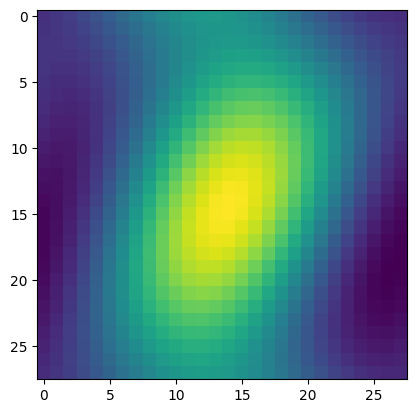

tensor(-0.9494) tensor(-0.7246) tensor(-0.4187)


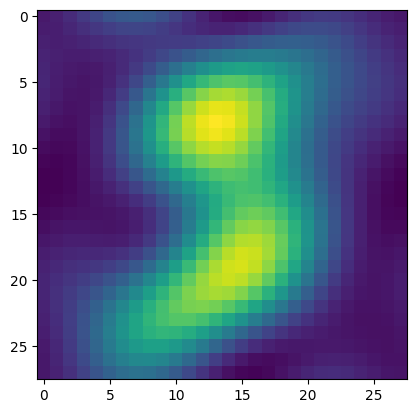

tensor(-1.1312) tensor(-0.7246) tensor(0.1482)


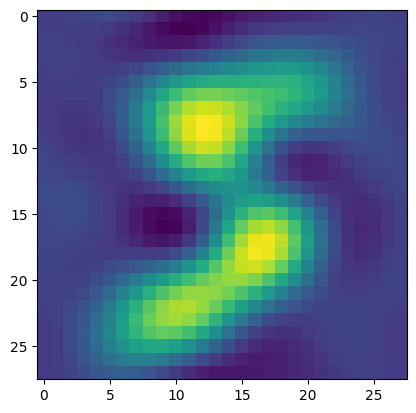

tensor(-1.3870) tensor(-0.7246) tensor(0.6216)


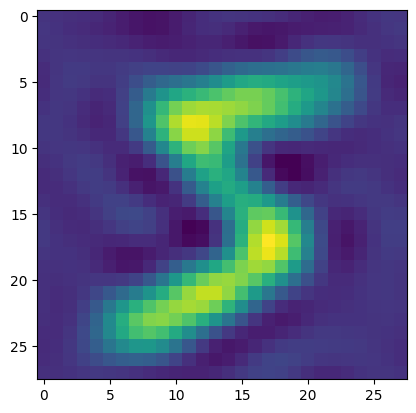

tensor(-1.3275) tensor(-0.7246) tensor(0.9087)


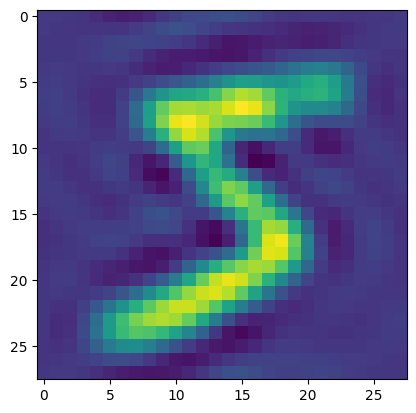

tensor(-1.4034) tensor(-0.7246) tensor(1.0859)


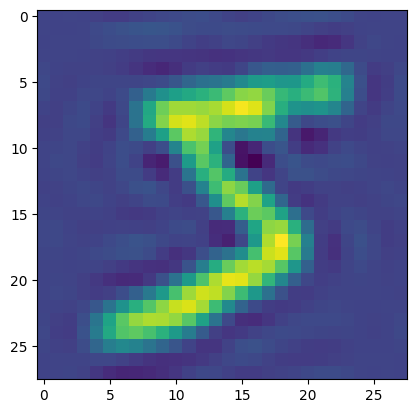

tensor(-1.5751) tensor(-0.7246) tensor(1.2537)


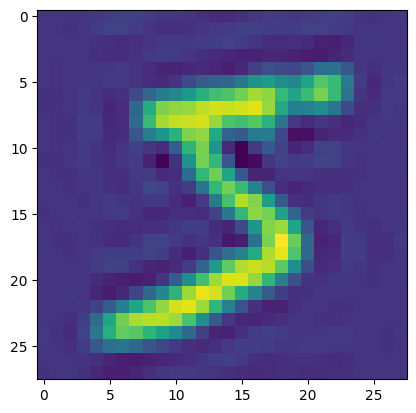

tensor(-1.4184) tensor(-0.7246) tensor(1.3140)


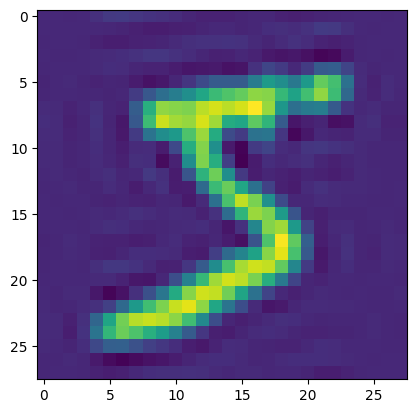

tensor(-1.3050) tensor(-0.7246) tensor(1.3779)


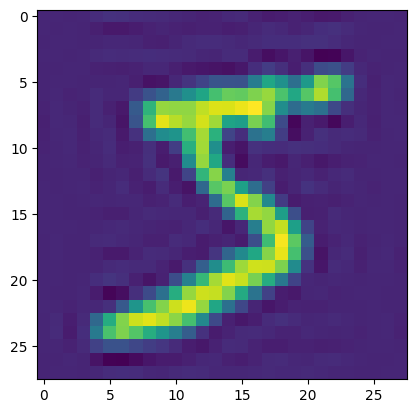

tensor(-1.2779) tensor(-0.7246) tensor(1.3495)


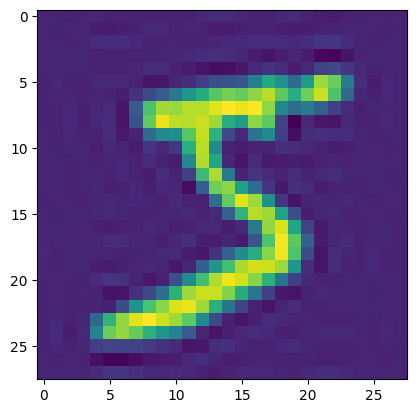

tensor(-1.2638) tensor(-0.7246) tensor(1.2939)


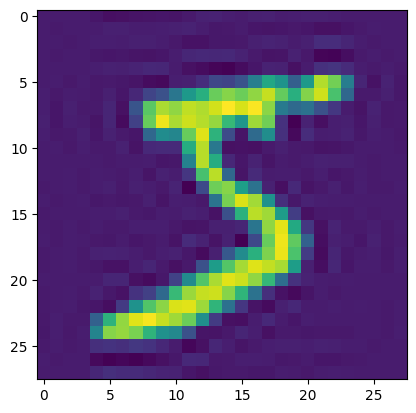

tensor(-1.1861) tensor(-0.7246) tensor(1.2699)


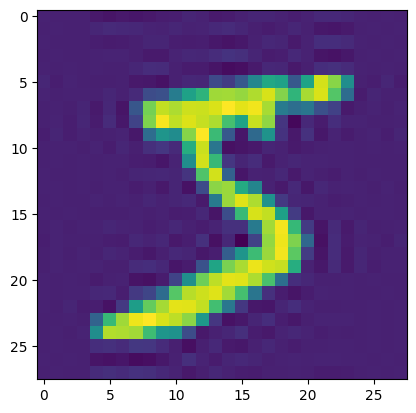

tensor(-1.2255) tensor(-0.7246) tensor(1.1873)


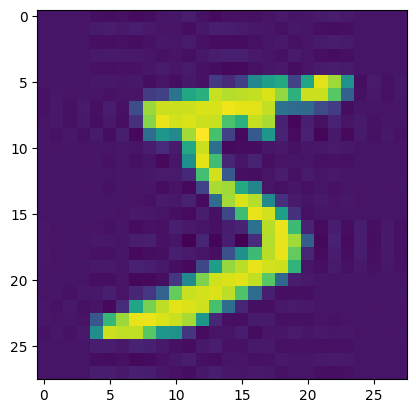

tensor(-1.1287) tensor(-0.7246) tensor(1.1420)


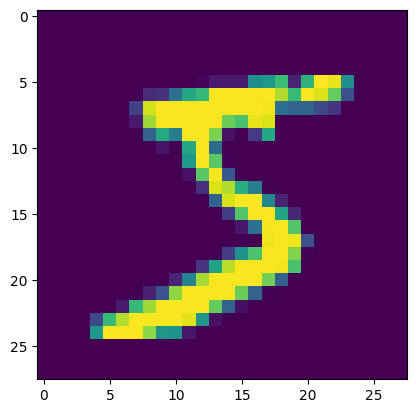

tensor(-1.0000) tensor(-0.7246) tensor(1.0000)


In [13]:
for n in range(1, 15):

    src = fft_forward_process(our_sample, n)


    plt.imshow(src)
    plt.show()
    # plt.imshow(dst)
    # plt.show()
    print(src.min(), src.mean(), src.max())

In [14]:
# NUM_SING_VAL = 10

In [15]:
# losses = []

# log_every_n = 10
# num_train_steps = 200
# num_epoches = 10
# step = 0 
# HIGH = 14


# for epoch in range(num_epoches):
#     for images, labels in tqdm(train_loader):
#         batch_src = []
#         batch_dst = []

#         rec_step = torch.randint(size=(images.shape[0],), low=1, high=HIGH - 1)
                
#         for i in range(images.shape[0]):
#             our_sample = images[i][0]
    
#             n = rec_step[i]
        
#             fft = torch.fft.fft2(our_sample)
#             shifted_fft = torch.fft.fftshift(fft)
            
#             shifted_fft[:, :HIGH-n] = 0
#             shifted_fft[:HIGH-n, :] = 0
#             shifted_fft[:, -HIGH+n:] = 0
#             shifted_fft[-HIGH+n:, :] = 0

#             un_shifted_fft = torch.fft.ifftshift(shifted_fft)
#             restored_sample = torch.fft.ifft2(un_shifted_fft).real

#             src = restored_sample    
            
    
#             fft = torch.fft.fft2(our_sample)
#             shifted_fft = torch.fft.fftshift(fft)
            
#             shifted_fft[:, :HIGH - (n+1)] = 0
#             shifted_fft[:HIGH-(n+1), :] = 0
#             shifted_fft[:, -HIGH+(n+1):] = 0
#             shifted_fft[-HIGH+(n+1):, :] = 0
            
#             un_shifted_fft = torch.fft.ifftshift(shifted_fft)
#             restored_sample = torch.fft.ifft2(un_shifted_fft).real
            
#             dst = restored_sample
    
#             batch_src.append(src.unsqueeze(dim=0).unsqueeze(dim=0))
#             batch_dst.append(dst.unsqueeze(dim=0).unsqueeze(dim=0))
            
        
    
#         src = torch.cat(batch_src, dim=0)
#         dst = torch.cat(batch_dst, dim=0)
    
#         target = src - dst
    
#         output = model(src, rec_step)
        
#         loss = F.mse_loss(output, target)
    
#         if step % log_every_n == 0:
#             print(loss.item())
        
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()
    
#         losses.append(loss.item())
    
#         step += 1

In [16]:
losses = []

log_every_n = 10
num_train_steps = 200
num_epoches = 10
step = 0 
HIGH = 15

model.train()

for epoch in range(num_epoches):
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epoches}')
    for images, labels in pbar:
        batch_src = []
        batch_dst = []

        # rec_step = torch.randint(size=(images.shape[0],), low=1, high=HIGH - 1)

        # Bias sampling towards earlier steps using exponential distribution
        weights = torch.exp(-0.5 * torch.arange(1, HIGH - 1, dtype=torch.float))
        weights = weights / weights.sum()
        rec_step = torch.multinomial(weights, images.shape[0], replacement=True) + 1
                
        for i in range(images.shape[0]):
            our_sample = images[i][0]
            
            src = fft_forward_process(our_sample, rec_step[i])
            
            dst = fft_forward_process(our_sample, rec_step[i] + 1)
    
            batch_src.append(src.unsqueeze(dim=0).unsqueeze(dim=0))
            batch_dst.append(dst.unsqueeze(dim=0).unsqueeze(dim=0))
            
        src = torch.cat(batch_src, dim=0).to(DEVICE)
        dst = torch.cat(batch_dst, dim=0).to(DEVICE)
        target = dst.to(DEVICE)
        rec_step = rec_step.to(DEVICE)

        optimizer.zero_grad()
        output = model(src, rec_step)
        
        loss = F.l1_loss(output, target)
    
        if step % log_every_n == 0:
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    
        losses.append(loss.item())
    
        step += 1

Epoch 2/10:  54%|█████▎    | 502/938 [02:24<02:05,  3.48it/s, loss=0.041586]


KeyboardInterrupt: 

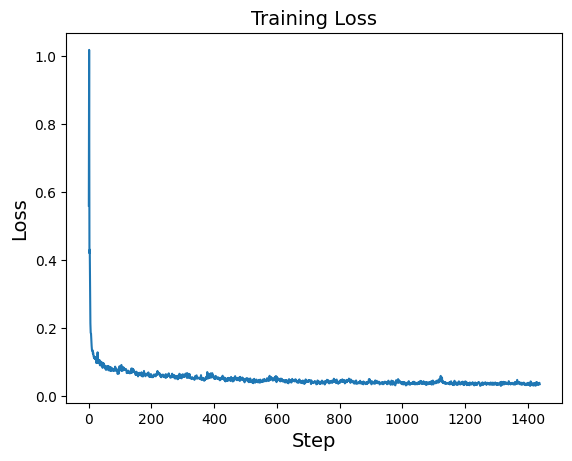

In [17]:
plt.plot([i for i in range(len(losses))], losses)
plt.xlabel('Step', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Training Loss', fontsize=14)
plt.show()


Fitted Gaussian on 1408 samples


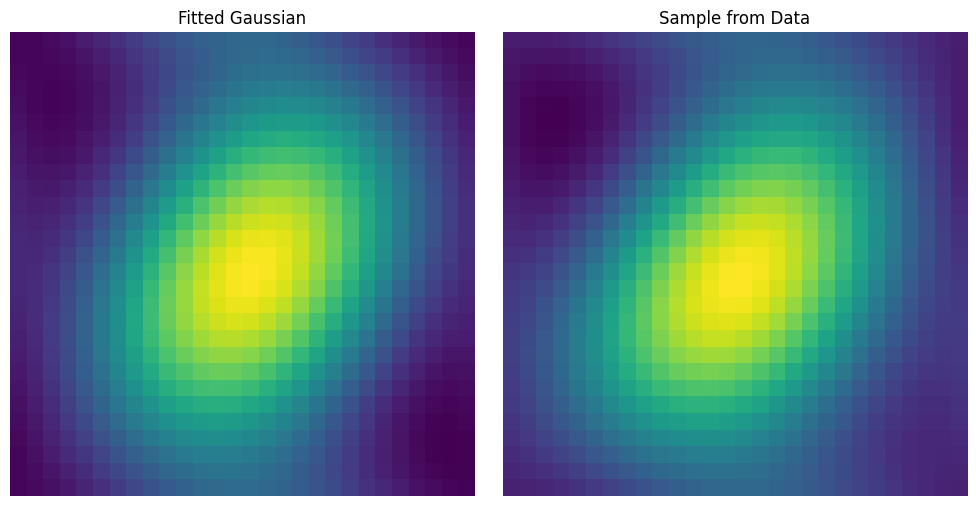

In [18]:
# Prior for FFT:
src_priors = []

for batch_num, (images, labels) in tqdm(enumerate(train_loader), desc='Collecting src(t=1) to compute prior'):
    rec_step = torch.randint(size=(images.shape[0],), low=1, high=HIGH - 1)
    for i in range(images.shape[0]):
        our_sample = images[i][0]
        
        src_prior = fft_forward_process(our_sample, 1)
        src_priors.append(src_prior)

    if batch_num > 20:
        break

def fit_gaussian_2d(samples_list):
    """
    Fit 2D Gaussian on n samples of 28x28 images.
    
    Args:
        samples_list: List of (28, 28) tensors
    
    Returns:
        mean: (28, 28) mean image
        cov: (784, 784) covariance matrix
    """
    samples = torch.stack([s.flatten() for s in samples_list])
    n_samples = samples.shape[0]
    
    mean = samples.mean(dim=0).view(28, 28)
    
    samples_centered = samples - samples.mean(dim=0, keepdim=True)
    cov = (samples_centered.T @ samples_centered) / (n_samples - 1)
    
    return mean, cov

def sample_from_gaussian(mean, cov, n_samples=1):
    """
    Sample from fitted 2D Gaussian distribution.
    
    Args:
        mean: (28, 28) mean tensor
        cov: (784, 784) covariance matrix
        n_samples: number of samples to generate
    
    Returns:
        samples of shape (n_samples, 28, 28)
    """
    mean_flat = mean.flatten()
    
    dist = torch.distributions.MultivariateNormal(
        mean_flat, 
        covariance_matrix=cov + 1e-6 * torch.eye(cov.shape[0])
    )
    
    samples = dist.sample((n_samples,))
    return samples.view(n_samples, 28, 28)

mean_img, cov_matrix = fit_gaussian_2d(src_priors)

print(f"Fitted Gaussian on {len(src_priors)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(mean_img)
axes[0].set_title('Fitted Gaussian')
axes[0].axis('off')

axes[1].imshow(src_priors[0])
axes[1].set_title('Sample from Data')
axes[1].axis('off')

plt.tight_layout()
plt.show()

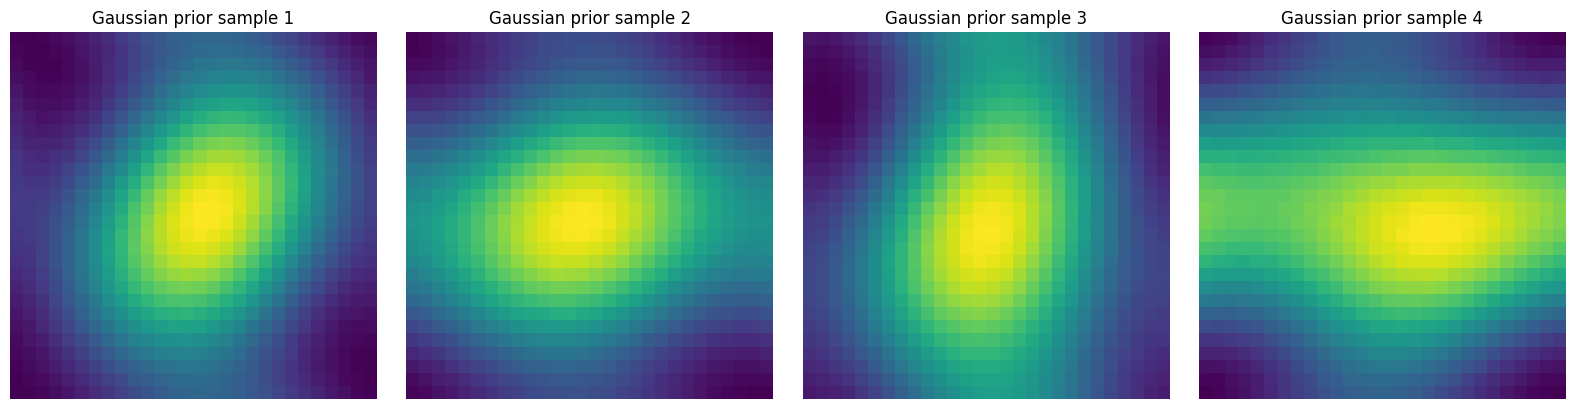

In [19]:
sampled_gaussian_prior = sample_from_gaussian(mean_img, cov_matrix, n_samples=4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].imshow(sampled_gaussian_prior[i])
    axes[i].set_title(f'Gaussian prior sample {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Union, List

def create_gaussian_heatmap(
    image_size: Tuple[int, int] = (28, 28),
    center: Optional[Tuple[float, float]] = None,
    sigma: Union[float, Tuple[float, float]] = 5.0,
    amplitude: float = 1.0,
    normalize: bool = True,
    random_offset: bool = False,
    random_sigma: bool = False,
    random_amplitude: bool = False
) -> np.ndarray:
    """
    Create a 2D Gaussian heatmap image in shape (1, H, W).
    
    Args:
        image_size: Size of the output image (height, width)
        center: Center of the Gaussian (y, x). If None, uses image center.
        sigma: Standard deviation(s) of the Gaussian. Can be a single value 
               for isotropic Gaussian or (sigma_y, sigma_x) for anisotropic.
        amplitude: Maximum value of the Gaussian peak
        normalize: If True, normalizes output to [0, 1]
        random_offset: If True, adds random offset to the center
        random_sigma: If True, randomizes sigma values
        random_amplitude: If True, randomizes amplitude
        
    Returns:
        numpy array of shape (1, height, width) containing the Gaussian heatmap
    """
    h, w = image_size
    
    # Set center coordinates
    if center is None:
        center_y, center_x = h / 2, w / 2
    else:
        center_y, center_x = center
    
    # Randomize parameters if requested
    if random_offset:
        max_offset = min(h, w) * 0.3  # Max 30% offset
        center_y += np.random.uniform(-max_offset, max_offset)
        center_x += np.random.uniform(-max_offset, max_offset)
    
    if random_sigma:
        if isinstance(sigma, tuple):
            sigma = (
                np.random.uniform(sigma[0] * 0.2, sigma[0] * 1.7),
                np.random.uniform(sigma[1] * 0.2, sigma[1] * 1.7)
            )
        else:
            sigma = np.random.uniform(sigma * 0.2, sigma * 1.7)
    
    if random_amplitude:
        amplitude = np.random.uniform(amplitude * 0.5, amplitude * 1.5)
    
    # Create coordinate grids
    y, x = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    
    # Handle different sigma formats
    if isinstance(sigma, tuple):
        sigma_y, sigma_x = sigma
    else:
        sigma_y = sigma_x = sigma
    
    # Calculate Gaussian
    gaussian = amplitude * np.exp(
        -(
            ((y - center_y) ** 2) / (2 * sigma_y ** 2) +
            ((x - center_x) ** 2) / (2 * sigma_x ** 2)
        )
    )
    
    if normalize:
        gaussian = (gaussian - gaussian.min()) / (gaussian.max() - gaussian.min() + 1e-8)
    
    return gaussian[np.newaxis, ...]  # Shape: (1, H, W)


def sample_gaussian_heatmap_batch(
    num_samples: int = 16,
    image_size: Tuple[int, int] = (28, 28),
    sigma_range: Tuple[float, float] = (3, 8),
    center_range: Tuple[float, float] = (0.2, 0.8),
    anisotropic: bool = False,
    normalize_each: bool = True
) -> np.ndarray:
    """
    Sample a batch of Gaussian heatmap images with random parameters.
    
    Args:
        num_samples: Number of images to generate
        image_size: Size of each image (height, width)
        sigma_range: Range for random sigma values
        center_range: Relative range for center position (0-1 scale)
        anisotropic: If True, uses different sigma for x and y directions
        normalize_each: If True, normalizes each image independently
        
    Returns:
        Batch of heatmap images with shape (num_samples, 1, height, width)
    """
    batch = []
    h, w = image_size
    
    for _ in range(num_samples):
        # Random center position within specified relative range
        center_y = np.random.uniform(h * center_range[0], h * center_range[1])
        center_x = np.random.uniform(w * center_range[0], w * center_range[1])
        
        # Random sigma
        if anisotropic:
            sigma = (
                np.random.uniform(*sigma_range),
                np.random.uniform(*sigma_range)
            )
        else:
            sigma = np.random.uniform(*sigma_range)
        
        # Random amplitude
        amplitude = np.random.uniform(0.7, 1.3)
        
        # Create heatmap
        heatmap = create_gaussian_heatmap(
            image_size=image_size,
            center=(center_y, center_x),
            sigma=sigma,
            amplitude=amplitude,
            normalize=normalize_each,
            random_offset=False,
            random_sigma=False,
            random_amplitude=False
        )
        
        batch.append(heatmap)
    
    return np.array(batch)  # Shape: (num_samples, 1, H, W)

batch = sample_gaussian_heatmap_batch(
    num_samples=16,
    image_size=(28, 28),
    sigma_range=(15, 35),
    anisotropic=True
)

In [60]:
torch.save(model.state_dict(), 'fft_model_2M.pth')

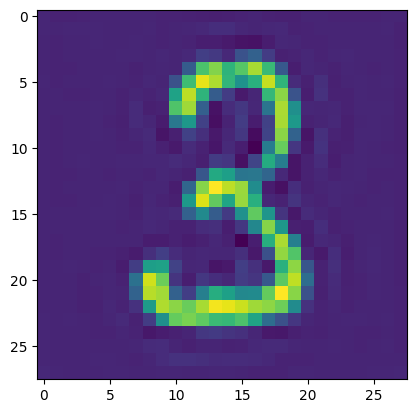

In [92]:
imgs = []
fig = plt.figure()

# x_t = src[None, None].to(DEVICE)
sampled_gaussian_prior = sample_from_gaussian(mean_img, cov_matrix, n_samples=16)
x_t = sampled_gaussian_prior[2][None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, 14):
    with torch.no_grad():
        x_t = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('generation.gif')

In [ ]:
x_t.unsqueeze(1).shape

torch.Size([1, 1, 1, 28, 28])

In [ ]:
imgs = []
fig = plt.figure()

# x_t = src[None, None].to(DEVICE)
sampled_gaussian_prior = sample_from_gaussian(mean_img, cov_matrix, n_samples=16)
x_t = sampled_gaussian_prior.unsqueeze(1).to(DEVICE)

model.eval()

for t in range(1, 8):
    with torch.no_grad():
        x_t = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )

<Figure size 640x480 with 0 Axes>

---
## FID:

In [ ]:
test_dataset = torchvision.datasets.MNIST(
        root='.', 
        train=False, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)
        ])
    )

### Saving Test MNIST set as images folder:

In [ ]:
# import os
# from PIL import Image

# save_dir = 'MNIST/fid_ref'
# os.makedirs(save_dir, exist_ok=True)

# count = 0
# for images, labels in tqdm(test_loader, desc='Saving test images'):
#     for i in range(images.shape[0]):
#         img = images[i]
        
#         # Convert from tensor to PIL Image
#         # Denormalize if needed (test_loader uses ToTensor without normalization)
#         img_np = (img.squeeze().numpy() * 255).astype(np.uint8)
#         pil_img = Image.fromarray(img_np, mode='L')
        
#         # Save image
#         pil_img.save(os.path.join(save_dir, f'test_{count:05d}.png'))
#         count += 1

# print(f'Saved {count} test images to {save_dir}')

Saving test images: 100%|██████████| 79/79 [00:16<00:00,  4.69it/s]

Saved 10000 test images to MNIST/fid_ref


<Figure size 640x480 with 0 Axes>

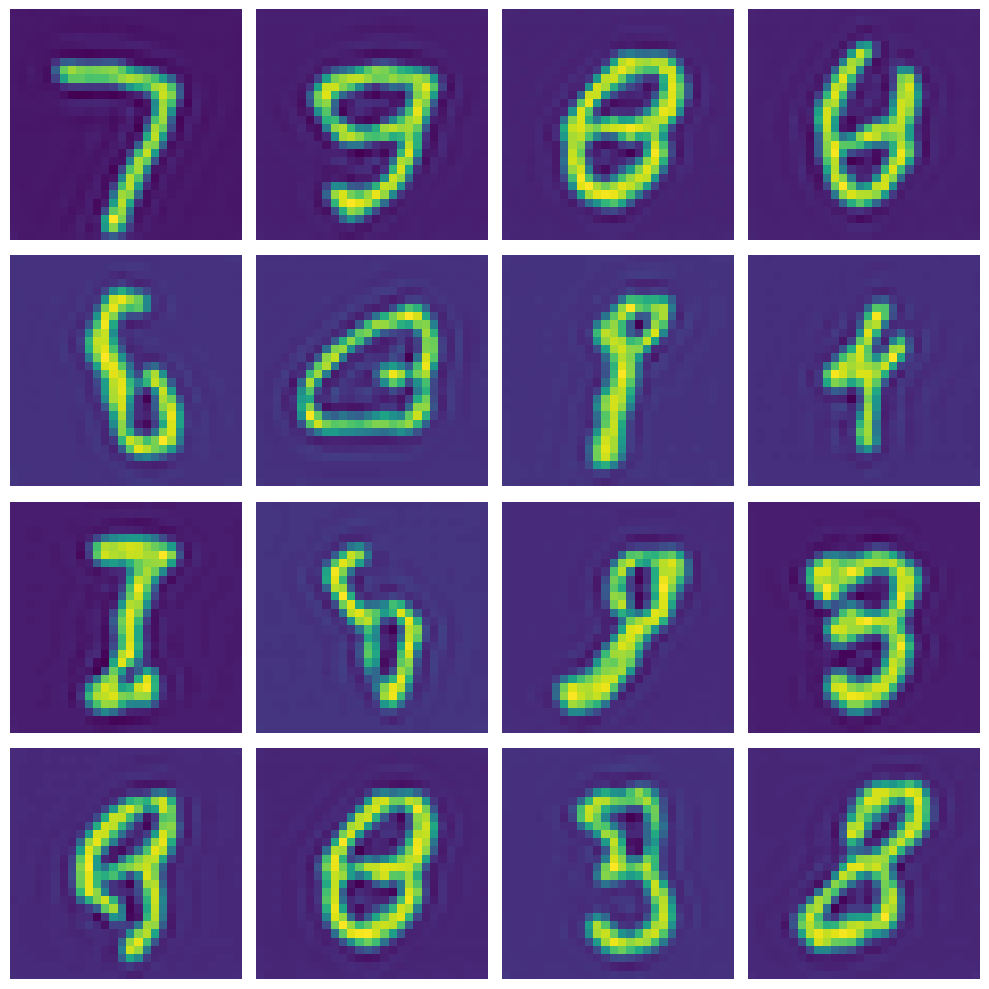

In [106]:
imgs = []
fig = plt.figure()

# x_t = src[None, None].to(DEVICE)
sampled_gaussian_prior = sample_from_gaussian(mean_img, cov_matrix, n_samples=16)
x_t = sampled_gaussian_prior.unsqueeze(1).to(DEVICE)

model.eval()

for t in range(1, 10):
    with torch.no_grad():
        x_t = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )

# Plot grid of batch images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(min(16, x_t.shape[0])):
    axes[i].imshow(x_t[i][0].cpu())
    axes[i].axis('off')

# Hide any unused subplots
for i in range(x_t.shape[0], 16):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [109]:
import os
from PIL import Image

num_samples = 10000
batch_size = 64
num_steps = 10

model.eval()

for num_steps in range(14, 15):
    save_dir = f'MNIST/generate_{num_steps}'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
        
        sampled_gaussian_prior = sample_from_gaussian(mean_img, cov_matrix, n_samples=current_batch_size)
        x_t = sampled_gaussian_prior.unsqueeze(1).to(DEVICE)
        
        with torch.no_grad():
            for t in range(1, num_steps):
                x_t = model(
                    x_t.to(DEVICE), 
                    torch.tensor(t).repeat(current_batch_size).to(DEVICE)
                )
        
        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

    print(f'Saved {count} generated images to {save_dir}')

Generating and saving images: 100%|██████████| 157/157 [00:22<00:00,  6.93it/s]

Saved 10000 generated images to MNIST/generate_14


In [132]:
import pandas as pd

fid_results = "fid_results.csv"
df = pd.read_csv(fid_results)
df = df.iloc[1:]

In [133]:
df["steps"] = df["path1"].apply(lambda x: int(x.split("_")[-1]))

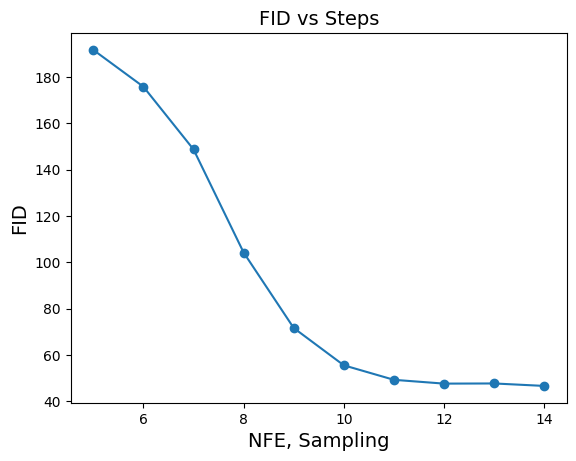

In [136]:
plt.plot(df["steps"], df["fid"], "-o")
plt.xlabel("NFE, Sampling", fontsize=14)
plt.ylabel("FID", fontsize=14)
plt.title("FID vs Steps", fontsize=14)
plt.show()


In [135]:
df

,path1,path2,fid,steps
1,MNIST/generate_5,MNIST/fid_ref,191.750568,5
2,MNIST/generate_6,MNIST/fid_ref,175.846057,6
3,MNIST/generate_7,MNIST/fid_ref,148.767713,7
4,MNIST/generate_8,MNIST/fid_ref,104.223747,8
5,MNIST/generate_9,MNIST/fid_ref,71.616539,9
6,MNIST/generate_10,MNIST/fid_ref,55.495030,10
7,MNIST/generate_11,MNIST/fid_ref,49.228748,11
8,MNIST/generate_12,MNIST/fid_ref,47.588099,12
9,MNIST/generate_13,MNIST/fid_ref,47.655613,13
10,MNIST/generate_14,MNIST/fid_ref,46.592179,14
